<a href="https://colab.research.google.com/github/nishthadighe-bit/Deep-Neural-Networks-and-Hyperparameter-Optimization/blob/main/task1_deep_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

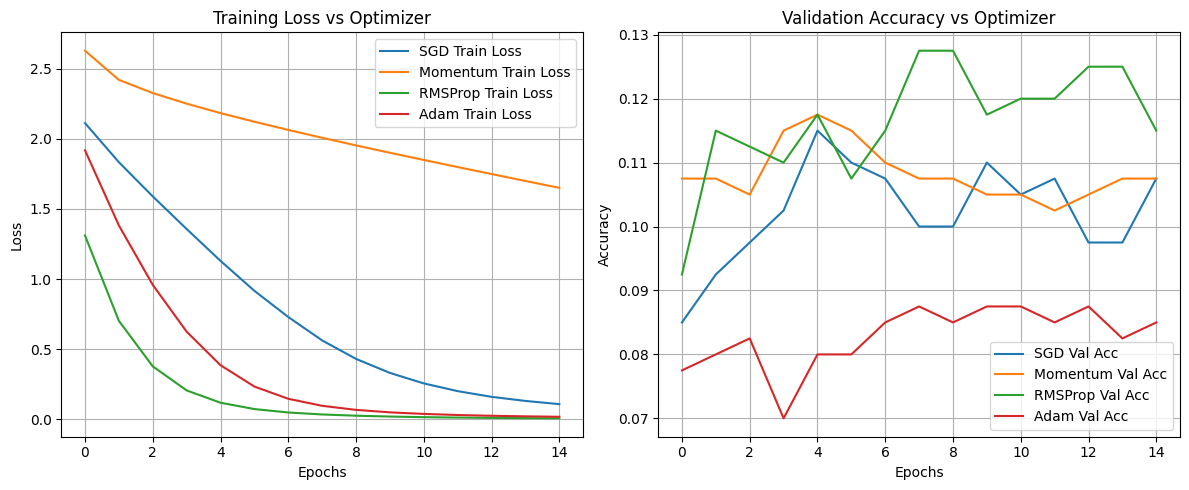

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Set random seed for reproducibility
np.random.seed(42)

# =====================================================================
# 1. ACTIVATION FUNCTIONS & DERIVATIVES
# =====================================================================
class Activations:
    @staticmethod
    def relu(Z):
        return np.maximum(0, Z)

    @staticmethod
    def relu_derivative(Z):
        return (Z > 0).astype(float)

    @staticmethod
    def sigmoid(Z):
        return 1.0 / (1.0 + np.exp(-np.clip(Z, -500, 500)))

    @staticmethod
    def sigmoid_derivative(Z):
        s = Activations.sigmoid(Z)
        return s * (1 - s)

    @staticmethod
    def softmax(Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)


# =====================================================================
# 2. OPTIMIZERS IMPLEMENTATION
# =====================================================================
class Optimizer:
    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, weights, biases, dw, db, layer_idx):
        raise NotImplementedError


class SGDOptimizer(Optimizer):
    def update(self, weights, biases, dw, db, layer_idx):
        weights -= self.lr * dw
        biases -= self.lr * db


class MomentumOptimizer(Optimizer):
    def __init__(self, lr=0.01, beta=0.9):
        super().__init__(lr)
        self.beta = beta
        self.v_w = {}
        self.v_b = {}

    def update(self, weights, biases, dw, db, layer_idx):
        if layer_idx not in self.v_w:
            self.v_w[layer_idx] = np.zeros_like(weights)
            self.v_b[layer_idx] = np.zeros_like(biases)

        self.v_w[layer_idx] = self.beta * self.v_w[layer_idx] + (1 - self.beta) * dw
        self.v_b[layer_idx] = self.beta * self.v_b[layer_idx] + (1 - self.beta) * db

        weights -= self.lr * self.v_w[layer_idx]
        biases -= self.lr * self.v_b[layer_idx]


class RMSPropOptimizer(Optimizer):
    def __init__(self, lr=0.001, beta=0.99, epsilon=1e-8):
        super().__init__(lr)
        self.beta = beta
        self.epsilon = epsilon
        self.s_w = {}
        self.s_b = {}

    def update(self, weights, biases, dw, db, layer_idx):
        if layer_idx not in self.s_w:
            self.s_w[layer_idx] = np.zeros_like(weights)
            self.s_b[layer_idx] = np.zeros_like(biases)

        self.s_w[layer_idx] = self.beta * self.s_w[layer_idx] + (1 - self.beta) * (dw ** 2)
        self.s_b[layer_idx] = self.beta * self.s_b[layer_idx] + (1 - self.beta) * (db ** 2)

        weights -= self.lr * dw / (np.sqrt(self.s_w[layer_idx]) + self.epsilon)
        biases -= self.lr * db / (np.sqrt(self.s_b[layer_idx]) + self.epsilon)


class AdamOptimizer(Optimizer):
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        super().__init__(lr)
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m_w, self.v_w = {}, {}
        self.m_b, self.v_b = {}, {}
        self.t = {}

    def update(self, weights, biases, dw, db, layer_idx):
        if layer_idx not in self.m_w:
            self.m_w[layer_idx] = np.zeros_like(weights)
            self.v_w[layer_idx] = np.zeros_like(weights)
            self.m_b[layer_idx] = np.zeros_like(biases)
            self.v_b[layer_idx] = np.zeros_like(biases)
            self.t[layer_idx] = 0

        self.t[layer_idx] += 1
        t = self.t[layer_idx]

        # First and second moment estimates
        self.m_w[layer_idx] = self.beta1 * self.m_w[layer_idx] + (1 - self.beta1) * dw
        self.m_b[layer_idx] = self.beta1 * self.m_b[layer_idx] + (1 - self.beta1) * db
        self.v_w[layer_idx] = self.beta2 * self.v_w[layer_idx] + (1 - self.beta2) * (dw ** 2)
        self.v_b[layer_idx] = self.beta2 * self.v_b[layer_idx] + (1 - self.beta2) * (db ** 2)

        # Bias correction
        m_w_corrected = self.m_w[layer_idx] / (1 - self.beta1 ** t)
        m_b_corrected = self.m_b[layer_idx] / (1 - self.beta1 ** t)
        v_w_corrected = self.v_w[layer_idx] / (1 - self.beta2 ** t)
        v_b_corrected = self.v_b[layer_idx] / (1 - self.beta2 ** t)

        weights -= self.lr * m_w_corrected / (np.sqrt(v_w_corrected) + self.epsilon)
        biases -= self.lr * m_b_corrected / (np.sqrt(v_b_corrected) + self.epsilon)


# =====================================================================
# 3. MODULAR NEURAL NETWORK ARCHITECTURE
# =====================================================================
class ModularNeuralNetwork:
    def __init__(self, layer_sizes, activation='relu'):
        self.layer_sizes = layer_sizes
        self.num_layers = len(layer_sizes)
        self.activation_type = activation
        self.weights = []
        self.biases = []
        self._initialize_weights()

    def _initialize_weights(self):
        for i in range(len(self.layer_sizes) - 1):
            n_in = self.layer_sizes[i]
            n_out = self.layer_sizes[i + 1]

            # He Initialization for ReLU, Xavier for Sigmoid
            if self.activation_type == 'relu':
                w = np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)
            else:
                w = np.random.randn(n_in, n_out) * np.sqrt(1.0 / n_in)

            b = np.zeros((1, n_out))
            self.weights.append(w)
            self.biases.append(b)

    def forward(self, X):
        activations = [X]
        z_values = []

        A = X
        for i in range(self.num_layers - 2):
            Z = np.dot(A, self.weights[i]) + self.biases[i]
            z_values.append(Z)

            if self.activation_type == 'relu':
                A = Activations.relu(Z)
            elif self.activation_type == 'sigmoid':
                A = Activations.sigmoid(Z)
            activations.append(A)

        # Output Layer (Softmax for multi-class classification)
        Z_out = np.dot(A, self.weights[-1]) + self.biases[-1]
        z_values.append(Z_out)
        A_out = Activations.softmax(Z_out)
        activations.append(A_out)

        return activations, z_values

    def backward(self, activations, z_values, Y_one_hot):
        m = Y_one_hot.shape[0]
        gradients = []

        # Cross-Entropy derivative with Softmax: dZ = A_out - Y
        dZ = activations[-1] - Y_one_hot

        for i in reversed(range(self.num_layers - 1)):
            A_prev = activations[i]
            dW = np.dot(A_prev.T, dZ) / m
            dB = np.sum(dZ, axis=0, keepdims=True) / m

            gradients.append((dW, dB))

            if i > 0:
                Z_prev = z_values[i - 1]
                if self.activation_type == 'relu':
                    da = Activations.relu_derivative(Z_prev)
                elif self.activation_type == 'sigmoid':
                    da = Activations.sigmoid_derivative(Z_prev)

                dZ = np.dot(dZ, self.weights[i].T) * da

        gradients.reverse()
        return gradients

    def compute_loss(self, Y_hat, Y_one_hot):
        m = Y_one_hot.shape[0]
        epsilon = 1e-12
        Y_hat = np.clip(Y_hat, epsilon, 1.0 - epsilon)
        loss = -np.sum(Y_one_hot * np.log(Y_hat)) / m
        return loss

    def fit(self, X, Y, X_val=None, Y_val=None, epochs=20, batch_size=64, optimizer=None):
        num_classes = len(np.unique(Y))
        Y_one_hot = np.eye(num_classes)[Y]

        if Y_val is not None:
            Y_val_one_hot = np.eye(num_classes)[Y_val]

        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        m = X.shape[0]

        for epoch in range(epochs):
            # Shuffle dataset per epoch
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            Y_shuffled = Y_one_hot[indices]

            # Mini-batch splitting
            for i in range(0, m, batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                Y_batch = Y_shuffled[i:i + batch_size]

                activations, z_values = self.forward(X_batch)
                gradients = self.backward(activations, z_values, Y_batch)

                for idx, (dW, dB) in enumerate(gradients):
                    optimizer.update(self.weights[idx], self.biases[idx], dW, dB, idx)

            # Record metrics
            train_acts, _ = self.forward(X)
            train_loss = self.compute_loss(train_acts[-1], Y_one_hot)
            train_acc = np.mean(np.argmax(train_acts[-1], axis=1) == Y)

            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)

            if X_val is not None:
                val_acts, _ = self.forward(X_val)
                val_loss = self.compute_loss(val_acts[-1], Y_val_one_hot)
                val_acc = np.mean(np.argmax(val_acts[-1], axis=1) == Y_val)
                history['val_loss'].append(val_loss)
                history['val_acc'].append(val_acc)

        return history


# =====================================================================
# 4. DATASET GENERATION & HYPERPARAMETER TUNING SUITE
# =====================================================================
def load_synthetic_mnist(samples=2000, n_features=784, n_classes=10):
    """Generates synthetic dataset mimicking MNIST for execution self-containment."""
    X = np.random.randn(samples, n_features)
    y = np.random.randint(0, n_classes, size=(samples,))
    # Simple scaling
    X = (X - np.mean(X)) / np.std(X)
    return X[:1600], y[:1600], X[1600:], y[1600:]

# Load synthetic dataset
X_train, y_train, X_val, y_val = load_synthetic_mnist()

# Optimizer Comparison
optimizers_to_test = {
    'SGD': SGDOptimizer(lr=0.05),
    'Momentum': MomentumOptimizer(lr=0.01, beta=0.9),
    'RMSProp': RMSPropOptimizer(lr=0.001),
    'Adam': AdamOptimizer(lr=0.001)
}

results = {}
for name, opt in optimizers_to_test.items():
    model = ModularNeuralNetwork(layer_sizes=[784, 128, 64, 10], activation='relu')
    hist = model.fit(X_train, y_train, X_val, y_val, epochs=15, batch_size=64, optimizer=opt)
    results[name] = hist

# Plotting Loss Curves for Comparative Analysis
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for name, hist in results.items():
    plt.plot(hist['train_loss'], label=f'{name} Train Loss')
plt.title('Training Loss vs Optimizer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for name, hist in results.items():
    plt.plot(hist['val_acc'], label=f'{name} Val Acc')
plt.title('Validation Accuracy vs Optimizer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()